O autor utilizou o AI Asssitant da IDE PyCharm 2025.3.4 para debugar

In [4]:
import math
import os
from pathlib import Path

import PIL
import matplotlib.pyplot as plt #3.10.8
import matplotlib.image as imread
import seaborn as sns #0.13.2
import numpy as np #2.4.4
import pandas as pd #3.0.2
from PIL import Image #12.1.1
import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.models import vgg16
from yellowbrick.cluster import SilhouetteVisualizer, KElbowVisualizer
from sklearn.cluster import KMeans



In [5]:
# Config dataset
TRAIN_PATH = Path('train')
TEST_PATH = Path('test')
LABELS_TRAIN_PATH = Path('labels', 'train_gabarito.csv')

Tamanho do dataset e distribuição de classes

In [6]:
files_train_gen = TRAIN_PATH.glob('*.*')
files_train_path_list = [file for file in files_train_gen]

files_test_gen = TEST_PATH.glob('*.*')
files_test_path_list = [file for file in files_test_gen]

print(f'Training size: {len(files_train_path_list)}')
print(f'Testing size: {len(files_test_path_list)}')

Training size: 800
Testing size: 200


In [7]:
labels_train_df = pd.read_csv(LABELS_TRAIN_PATH)
labels_train_df.head()


,Nome,Label
0,Good_data03_good (422).jpg,1
1,Bad_data01_bad (369).jpg,0
2,Good_data03_good (332).jpg,1
3,Bad_data01_bad (457).jpg,0
4,Good_data03_good (364).jpg,1


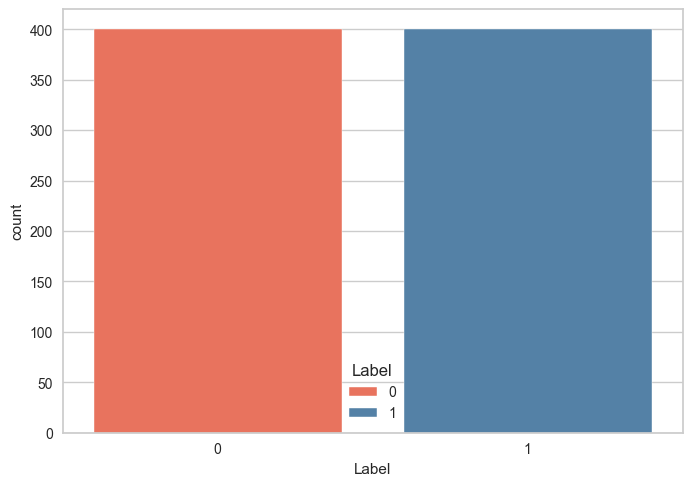

In [8]:
_ = sns.countplot(data=labels_train_df, x ='Label', hue='Label', palette={0: 'tomato', 1: 'steelblue'})
plt.show()

In [9]:
labels_train_df.value_counts(["Label"], normalize=True)

Label
1        0.5
0        0.5
Name: proportion, dtype: float64

Checks de sanidade

In [10]:
class SanityChecks:
    def __init__(self, path: Path) -> None:
        self.path = path
        self.files_list = self.__get_path_list()
        self.mode_types = []
        self.width = []
        self.height = []

    def __get_path_list(self) -> list:
        files_path_gen = self.path.glob('*.*')
        return [file for file in files_path_gen]

    def check_corruption(self) -> dict:
        error = []
        for file in self.files_list:
            try:
                img = Image.open(file)
                self.mode_types.append(img.mode)
                self.width.append(img.width)
                self.height.append(img.height)
            except:
                error.append(file)
        return {
            'qt_errors': len(error), 'files_erros': error}

    def check_typing(self) -> dict:
        print(self.files_list[0])
        ext = [str(file).split('.')[-1] for file in self.files_list]
        return {
            "ext": list(set(ext))
        }
    def check_mode(self) -> dict:
        return {
            'modes': list(set(self.mode_types))
        }

    def check_dimensions (self) -> dict:
        return {
            'width': list(set(self.width)),
            'height': list(set(self.height))
        }

In [11]:
sanity_checks = SanityChecks(TRAIN_PATH)
print(sanity_checks.check_corruption())
print(sanity_checks.check_typing())
print(sanity_checks.check_mode())
print(sanity_checks.check_dimensions())

{'qt_errors': 0, 'files_erros': []}
train\Bad_data01_bad (1).jpg
{'ext': ['jpg']}
{'modes': ['RGB']}
{'width': [517, 518, 520, 1546, 527, 1040, 1044, 1556, 1558, 1563, 540, 1568, 1578, 1068, 1071, 1584, 1586, 1599, 1600, 1089, 1099, 1102, 1105, 1109, 1118, 1119, 1125, 1126, 1153, 1155, 1162, 1172, 1175, 1184, 1186, 1188, 1189, 1196, 1198, 1209, 1212, 1214, 1218, 1224, 1230, 1234, 1236, 1237, 5339, 1248, 1249, 738, 1252, 1253, 5866, 1259, 1261, 1267, 1271, 1273, 1277, 1280, 1284, 1289, 1293, 1296, 1308, 1317, 1331, 1333, 1334, 1335, 1337, 1338, 1339, 1341, 1352, 1355, 1356, 1357, 1361, 1364, 1373, 1376, 1397, 1399, 1408, 1413, 1418, 1421, 1427, 1428, 1434, 1441, 1446, 424, 1453, 942, 437, 1463, 1467, 1471, 1474, 965, 1478, 975, 466, 468, 1494, 1500, 479, 1505, 487, 492, 1523, 1532], 'height': [1537, 517, 518, 520, 1547, 1549, 5136, 1042, 1561, 1049, 539, 540, 1575, 1066, 1072, 562, 1081, 1084, 1600, 1113, 1115, 1116, 1122, 1124, 1136, 1150, 1155, 1160, 1170, 1182, 1183, 1187, 1190, 1191

In [12]:
sanity_checks = SanityChecks(TEST_PATH)
print(sanity_checks.check_corruption())
print(sanity_checks.check_typing())
print(sanity_checks.check_mode())
print(sanity_checks.check_dimensions())

{'qt_errors': 0, 'files_erros': []}
test\Bad_data01_bad (10).jpg
{'ext': ['jpg']}
{'modes': ['RGB']}
{'width': [1280, 1153, 1408, 1155, 1284, 1413, 1546, 1162, 1421, 1040, 1296, 1427, 1428, 1556, 1172, 1175, 1558, 1308, 540, 1184, 1568, 1186, 1188, 1317, 1189, 1446, 1068, 1453, 1071, 1584, 1333, 1078, 1463, 1335, 1209, 1338, 1339, 1467, 1341, 1214, 1471, 1600, 1474, 1478, 1224, 1352, 1355, 1356, 1357, 1230, 1361, 1234, 1236, 1109, 1364, 1494, 1500, 1373, 1119, 1376, 1505, 738, 1248, 1249, 1253, 1259, 1267, 1523, 1397, 1399, 1271, 1532], 'height': [512, 1280, 1537, 1155, 1284, 1409, 1286, 1160, 1417, 1547, 1420, 1293, 1291, 1549, 1296, 1170, 1427, 1304, 1561, 1433, 539, 540, 1437, 1049, 1183, 1190, 1575, 1191, 1066, 1451, 1197, 1326, 1456, 1200, 1202, 1075, 1204, 1081, 1338, 1467, 1209, 1465, 1470, 1215, 1600, 1217, 1346, 1348, 1477, 1476, 1351, 1227, 1356, 1357, 1230, 1228, 1232, 1361, 1364, 1237, 1242, 1115, 1500, 737, 1251, 1254, 1388, 1389, 1390, 1266, 1399, 1274, 1150]}


In [13]:
def plot_images(path: Path, sample_size: int):
    files_path_gen = path.glob('*.*')
    files = [file for file in files_path_gen]

    sample = np.random.choice(files, sample_size)

    cols = math.ceil(math.sqrt(sample_size))
    rows = math.ceil(math.sqrt(sample_size))

    plt.figure(figsize=(10,10))
    plt.suptitle(f'Sample of {sample_size} images from {path}')
    for i, file in enumerate(sample):
        img = Image.open(file)
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

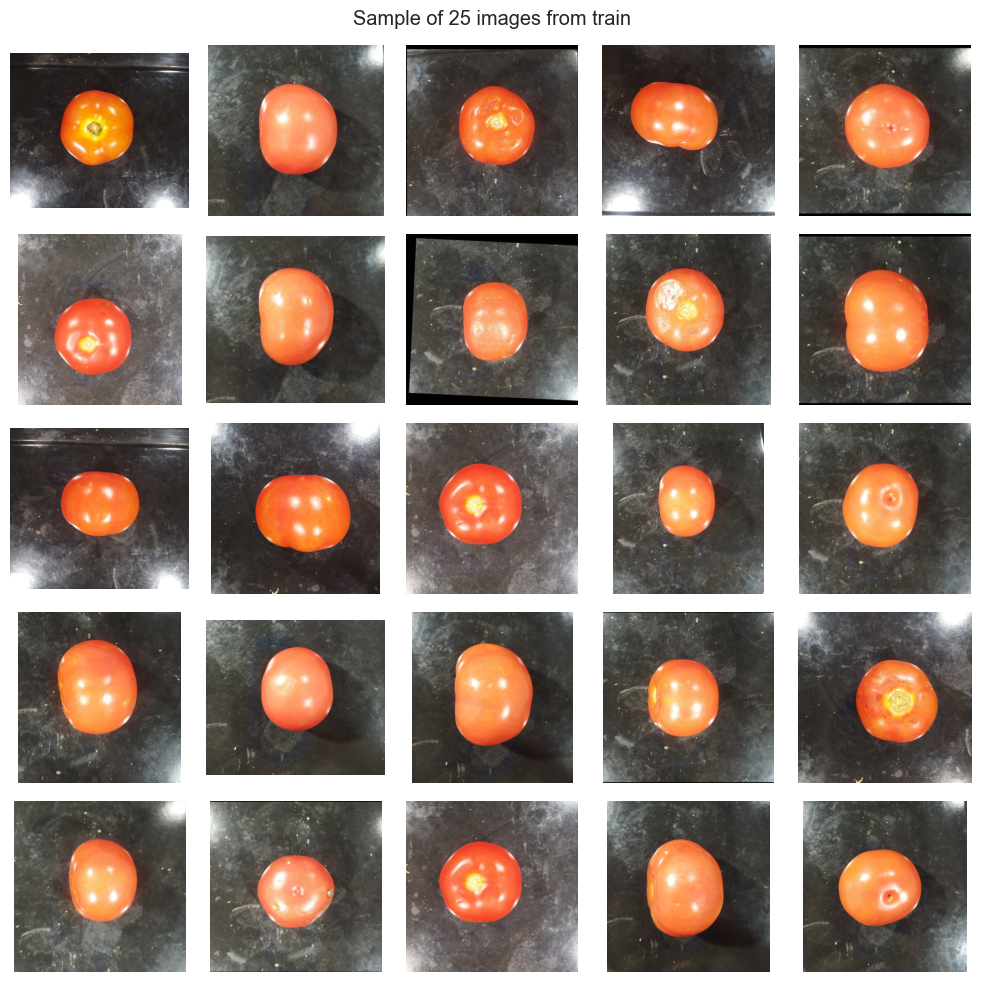

In [14]:
plot_images(TRAIN_PATH, sample_size=25)

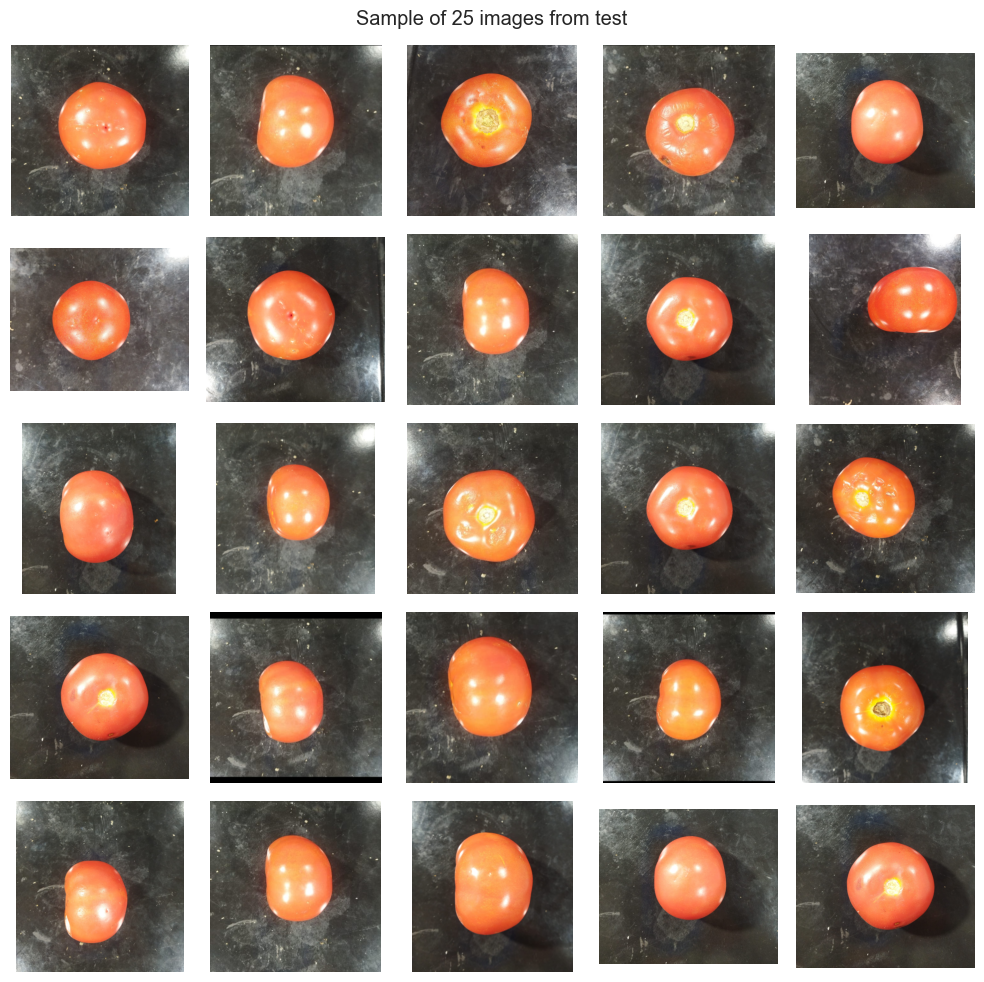

In [15]:
plot_images(TEST_PATH, sample_size=25)

Visualizando a distribuição de pixels

In [16]:
class PixelsVerify:
    def __init__(self, path: Path, labels_path: Path) -> None:
        self.train_path = path
        self.files = self.__get_path_list()
        self.labels_train_df = pd.read_csv(labels_path)
        self.sample = []
        self.rows = None
        self.cols = None

        self.labels_map = dict(
            zip(self.labels_train_df["Nome"], self.labels_train_df["Label"])
        )

    def __get_path_list(self) -> list:
        files_path_gen = self.train_path.glob("*.*")
        return [file for file in files_path_gen]

    def __get_rgb_pixels(self, image):
        pixels = image.histogram()
        return {
            "r": pixels[:256],
            "g": pixels[256:512],
            "b": pixels[512:]
        }

    def plot_histograms(self, sample_size):
        self.sample = np.random.choice(self.files, sample_size)

        # Pair each file with its labels directly
        samples_with_labels = [
            (file, self.labels_map.get(file.name, "unknown"))
            for file in self.sample
        ]

        self.cols = math.ceil(math.sqrt(sample_size))
        self.rows = math.ceil(math.sqrt(sample_size))

        plt.figure(figsize=(10, 10))
        plt.suptitle("Sample of histograms from database")

        for i, (file, label) in enumerate(samples_with_labels):
            img = Image.open(file)
            pixels = self.__get_rgb_pixels(img)

            plt.subplot(self.rows, self.cols, i + 1)
            plt.plot(list(range(256)), pixels["r"], color="Red")
            plt.plot(list(range(256)), pixels["g"], color="Green")
            plt.plot(list(range(256)), pixels["b"], color="Blue")
            plt.title(f"{file.name} - {label}")

        plt.tight_layout()
        plt.show()
    def plot_imgs_from_histograms(self):
        plt.figure(figsize=(10,10))
        plt.suptitle(f'Imagens aleatórias referentes aos histogramas')
        for i, file in enumerate(self.sample):
            img = Image.open(file)
            plt.subplot(self.rows, self.cols, i+1)
            plt.imshow(img)
            plt.title(file.name)
            plt.axis('off')

        plt.tight_layout()
        plt.show()


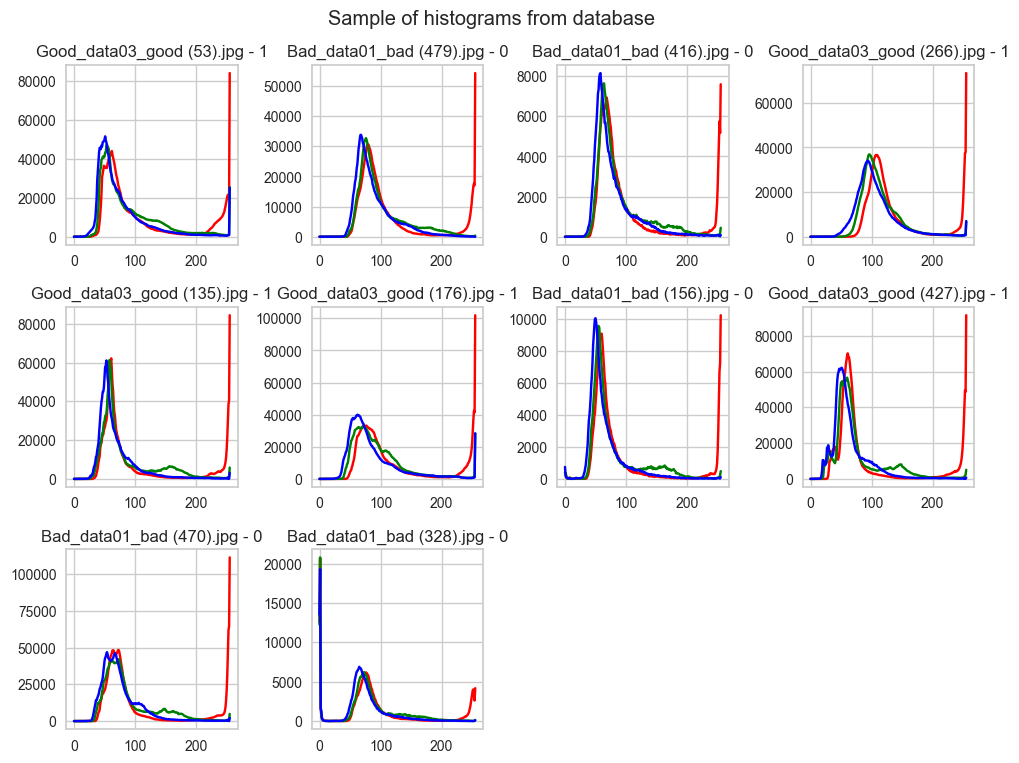

In [17]:
pixels = PixelsVerify(TRAIN_PATH, LABELS_TRAIN_PATH)
pixels.plot_histograms(sample_size=10)

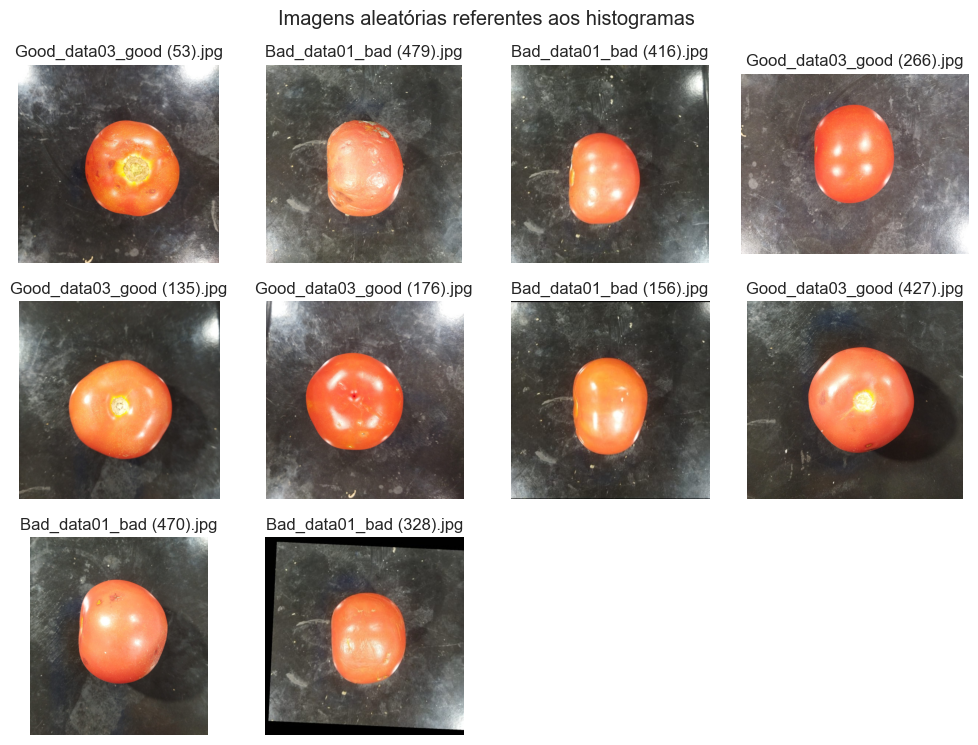

In [18]:
pixels.plot_imgs_from_histograms()

Novo aqui para frente

Criando matriz de features com Deep Learning

In [19]:
vgg16 = models.vgg16(weights=True)
vgg16

C:\Users\limad\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [20]:
class VGG16Extractor(nn.Module):
    def __init__(self, model):
        super(VGG16Extractor, self).__init__()
        self.features = model.features
        self.pooling = model.avgpool
        self.flatten = nn.Flatten()
        self.fc = model.classifier[0]

    def forward (self, x):
        out = nn.Sequential(self.features, self.pooling, self.flatten, self.fc)
        out = out(x)
        return out

In [21]:
device = 'cpu'
feature_extractor_model = VGG16Extractor(vgg16).to(device)

In [22]:
class FeatureExtractor:
    def __init__(self, model, file_dir, device):
        self.model = model
        self.file_dir = file_dir
        self.device = device
        self.files = self.__get_path_list()
        self.transformers = self.__get_transformers()

    def __get_path_list(self):
        files_path_gen = self.file_dir.glob('*.*')
        return [file for file in files_path_gen]

    def __get_transformers(self):
        transformers = transforms.Compose([
            transforms.Resize((448, 448)),
            # entrada do VGG16
            transforms.ToTensor(),
        ])
        return transformers

    def __get_features(self, file):
        img = Image.open(file).convert("RGB")
        img = self.transformers(img)
        img = img.unsqueeze(0)  # batch dimension: [1, 3, 448, 448]
        img = img.to(self.device)

        with torch.no_grad():
            features = self.model(img)

        return features

    def get_features(self):
        features = []
        for i, file in enumerate(self.files):
            features.append(self.__get_features(file))
        return features


# feature_matrix = FeatureExtractor(
#     model=feature_extractor_model,
#     file_dir=TRAIN_PATH,
#     device=device
# ).get_features()

In [ ]:
feature_matrix = FeatureExtractor(
    model=feature_extractor_model,
    file_dir=TRAIN_PATH,
    device=device
).get_features()